# Chapter 4: Submersions, Immersions, and Embeddings

**Source Span.** `Introduction to Smooth Manifolds.pdf`, Chapter 4, printed pages `77-97` (extracted from PDF pages `95-115` after checking the page offset against the source map).

**Chapter Goal.** Learn how the rank of the differential controls the local shape of a smooth map, and how the three full-rank cases - submersions, immersions, and embeddings - behave in examples, counterexamples, quotient tests, and covering maps.

The source span is used here for terminology, theorem orientation, page span, and example coverage. The prose, diagrams, computations, and checks below are original teaching material. The guiding question is: when can a nonlinear map be trusted to look like a linear map after choosing the right local coordinates?


In [1]:
from pathlib import Path
import json
import math
import sys

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import plotly.graph_objects as go
import sympy as sp
from IPython.display import Markdown, display
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

def locate_book_root():
    starts = [Path.cwd(), Path.cwd() / "Introduction-to-Smooth-Manifolds"]
    for start in starts:
        for candidate in [start, *start.parents]:
            if (candidate / "AGENTS.md").exists() and (candidate / "source_map.json").exists() and (candidate / "utils").exists():
                return candidate
    raise RuntimeError("Could not locate Introduction-to-Smooth-Manifolds root")

BOOK_ROOT = locate_book_root()
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import (
    assert_artifacts,
    chapter_artifact_root,
    display_artifact,
    ensure_parent,
    save_csv,
    save_json,
    save_matplotlib,
)

UNIT_KEY = "chapter-04-submersions-immersions-and-embeddings"
UNIT_TITLE = "Submersions, Immersions, and Embeddings"
SOURCE_SPAN = {
    "text": "Introduction to Smooth Manifolds.pdf, Chapter 4, printed pages 77-97",
    "pdf_pages_inspected": "95-115",
    "focus": "constant rank maps, local diffeomorphisms, rank theorem, embeddings, submersions, smooth covering maps",
}

ARTIFACT_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES = ARTIFACT_ROOT / "figures"
CHECKS = ARTIFACT_ROOT / "checks"
TABLES = ARTIFACT_ROOT / "tables"
HTML = ARTIFACT_ROOT / "html"

CREATED_ARTIFACTS = []
CHECK_SUMMARIES = {}

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
})

print(f"Book root: {BOOK_ROOT}")
print(f"Artifact root: {ARTIFACT_ROOT.relative_to(BOOK_ROOT)}")


Book root: D:\Geometry\Introduction-to-Smooth-Manifolds
Artifact root: artifacts\chapter-04-submersions-immersions-and-embeddings


## Visual Storyboard

1. **Proof dependency graph.** Track how full-rank tests feed the inverse function theorem, rank theorem, embeddings, quotient-like submersions, and smooth coverings.
2. **Rank as observable data.** Compare a projection, a regular curve, a cusp, and a fold by inspecting where the Jacobian has full rank or drops rank.
3. **Constant-rank normal forms.** Draw the rank theorem's three local models: rank `r`, submersion, and immersion.
4. **Inverse/local form check.** Use an explicit local diffeomorphism with a known inverse to make the inverse function theorem executable.
5. **Immersions vs embeddings.** Compare an embedded parabola, a cusp, a figure-eight style curve, and an irrational torus line.
6. **Submersions as projections and level-set tests.** Use gradients/Jacobians to distinguish regular fibers from singular zero sets.
7. **Smooth covering maps.** Show the exponential cover of the circle, its local sheets, and the uniqueness of local sections over an evenly covered arc.
8. **Applied lab.** Scan a one-parameter family and watch submersion status fail on predictable critical lines.

## Library Routing

| Concept | Representation | Library | Why this route fits | Artifact/check |
| --- | --- | --- | --- | --- |
| Rank and full-rank tests | Jacobian matrices, singular values, rank-drop loci | SymPy, NumPy, Matplotlib | Exact ranks plus visible failure sets | `rank-field-examples.*` |
| Rank theorem normal forms | Collapsed fibers, projections, coordinate planes | SymPy, Matplotlib 3D | The theorem is local linear algebra made geometric | `constant-rank-normal-forms.*` |
| Local diffeomorphism | Deformed grid with exact inverse residual | SymPy, NumPy, Matplotlib | Makes inverse theorem hypotheses measurable | `local-diffeomorphism-grid.*` |
| Immersion versus embedding | Curves and flat-torus parameter plot | NumPy, Matplotlib, Plotly | Separates differential injectivity from topology of the image | `immersion-embedding-counterexamples.*`, `dense-torus-immersion.html` |
| Submersions and level sets | Projection fibers, gradient fields, singular level sets | SymPy, NumPy, Matplotlib | Surjectivity of the differential becomes a rank/gradient test | `submersion-level-set-tests.*` |
| Smooth covering maps | Circle cover, lifted sheets, helix view | NumPy, Matplotlib, Plotly | Evenly covered neighborhoods and local sections are visual | `smooth-covering-local-sections.*` |
| Theorem flow | Directed dependency graph | NetworkX, Matplotlib | Proof moves are easier to inspect as a graph | `chapter04-proof-dependency-graph.*` |


In [2]:
routing_rows = [
    {"concept": "rank and full-rank tests", "representation": "Jacobian ranks and rank-drop loci", "library": "SymPy, NumPy, Matplotlib", "artifact": "rank-field-examples"},
    {"concept": "constant-rank normal forms", "representation": "fiber collapse and coordinate planes", "library": "SymPy, Matplotlib 3D", "artifact": "constant-rank-normal-forms"},
    {"concept": "local diffeomorphism", "representation": "grid image plus inverse residual", "library": "SymPy, NumPy, Matplotlib", "artifact": "local-diffeomorphism-grid"},
    {"concept": "immersions vs embeddings", "representation": "curve counterexamples and torus line", "library": "NumPy, Matplotlib, Plotly", "artifact": "immersion-embedding-counterexamples"},
    {"concept": "submersions and level sets", "representation": "projection fibers and regular/singular levels", "library": "SymPy, NumPy, Matplotlib", "artifact": "submersion-level-set-tests"},
    {"concept": "smooth covering maps", "representation": "circle sheets and helix cover", "library": "NumPy, Matplotlib, Plotly", "artifact": "smooth-covering-local-sections"},
    {"concept": "proof flow", "representation": "directed theorem graph", "library": "NetworkX, Matplotlib", "artifact": "chapter04-proof-dependency-graph"},
]
routing_path = save_csv(routing_rows, TABLES / "library-routing.csv")
CREATED_ARTIFACTS.append(routing_path)
display(Markdown(f"Saved library routing table: `{routing_path.relative_to(BOOK_ROOT)}`"))


Saved library routing table: `artifacts\chapter-04-submersions-immersions-and-embeddings\tables\library-routing.csv`

## Translation Guide

The chapter repeatedly translates a nonlinear question into a linear one:

- The **rank of a smooth map at a point** is the rank of its differential there.
- A **submersion** has surjective differential everywhere, so locally it behaves like a projection onto the target coordinates.
- An **immersion** has injective differential everywhere, so locally it behaves like the standard inclusion of a lower-dimensional coordinate plane.
- A **local diffeomorphism** is the square full-rank case: the differential is invertible, and the map has a smooth local inverse.
- A **smooth embedding** is stronger than an injective immersion: it also remembers the topology of the image.
- A **smooth covering map** is a local diffeomorphism with globally repeated sheets, so every small enough base neighborhood has diffeomorphic lifted copies.

The rank theorem is the central normal-form statement. It says that a constant-rank map can be straightened by charts until only the surviving rank coordinates remain visible. Most examples below ask the same question in different costumes: which coordinates survive the differential, which directions become fibers, and which topological condition cannot be seen by the Jacobian alone?


## Proof Dependency Graph

This graph is not a replacement for the proof, but it is a map of the chapter's proof traffic. The inverse function theorem supplies the local inverse case; the rank theorem generalizes it to constant rank; embeddings, local sections, quotient properties, and coverings are downstream consequences.


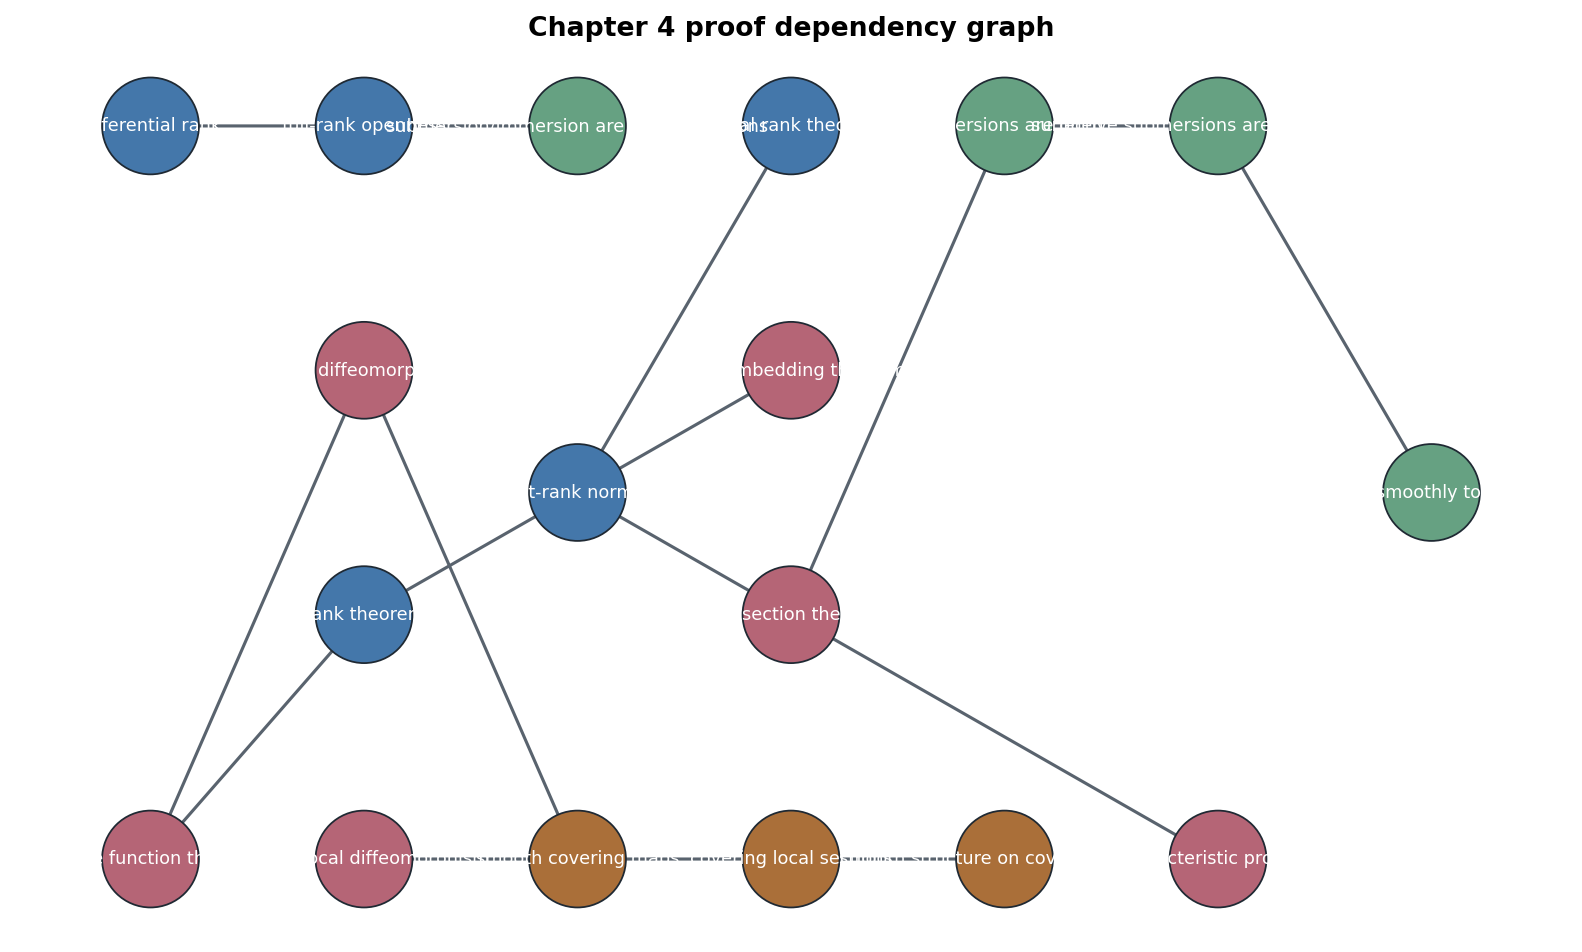

In [3]:
proof_edges = [
    ("differential rank", "full-rank openness"),
    ("full-rank openness", "submersion/immersion are local conditions"),
    ("inverse function theorem", "local diffeomorphism"),
    ("inverse function theorem", "rank theorem"),
    ("rank theorem", "constant-rank normal form"),
    ("constant-rank normal form", "global rank theorem"),
    ("constant-rank normal form", "local embedding theorem"),
    ("constant-rank normal form", "local section theorem"),
    ("local section theorem", "submersions are open"),
    ("submersions are open", "surjective submersions are quotient maps"),
    ("local section theorem", "characteristic property"),
    ("surjective submersions are quotient maps", "passing smoothly to quotient"),
    ("local diffeomorphism", "smooth covering maps"),
    ("smooth covering maps", "covering local sections"),
    ("covering local sections", "smooth structure on covering spaces"),
    ("proper local diffeomorphism", "smooth covering maps"),
]
PG = nx.DiGraph(proof_edges)
layers = {
    0: ["differential rank", "inverse function theorem"],
    1: ["full-rank openness", "local diffeomorphism", "rank theorem", "proper local diffeomorphism"],
    2: ["submersion/immersion are local conditions", "constant-rank normal form", "smooth covering maps"],
    3: ["global rank theorem", "local embedding theorem", "local section theorem", "covering local sections"],
    4: ["submersions are open", "smooth structure on covering spaces"],
    5: ["surjective submersions are quotient maps", "characteristic property"],
    6: ["passing smoothly to quotient"],
}
pos = {}
for layer, nodes in layers.items():
    offsets = np.linspace(1.0, -1.0, len(nodes)) if len(nodes) > 1 else np.array([0.0])
    for y_offset, node in zip(offsets, nodes):
        pos[node] = np.array([float(layer), float(y_offset)])
fig, ax = plt.subplots(figsize=(12.5, 7.2))
node_colors = []
for node in PG.nodes:
    if "rank" in node or "normal" in node:
        node_colors.append("#4477aa")
    elif "submersion" in node or "quotient" in node:
        node_colors.append("#66a182")
    elif "covering" in node:
        node_colors.append("#aa6f39")
    else:
        node_colors.append("#b56576")
nx.draw_networkx_edges(PG, pos, ax=ax, arrows=True, arrowstyle="-|>", width=1.4, edge_color="#59636e")
nx.draw_networkx_nodes(PG, pos, ax=ax, node_color=node_colors, node_size=1900, edgecolors="#1f2933", linewidths=0.8)
nx.draw_networkx_labels(PG, pos, ax=ax, font_size=8, font_color="white")
ax.set_title("Chapter 4 proof dependency graph")
ax.axis("off")
proof_graph_path = save_matplotlib(fig, FIGURES / "chapter04-proof-dependency-graph.png")
plt.close(fig)
proof_graph_check = {
    "nodes": PG.number_of_nodes(),
    "edges": PG.number_of_edges(),
    "is_directed_acyclic_graph": bool(nx.is_directed_acyclic_graph(PG)),
    "source_span": SOURCE_SPAN,
}
proof_graph_json = save_json(proof_graph_check, CHECKS / "chapter04-proof-dependency-graph.json")
CREATED_ARTIFACTS.extend([proof_graph_path, proof_graph_json])
CHECK_SUMMARIES["proof_dependency_graph"] = proof_graph_check
display_artifact(proof_graph_path, width=900)


## Rank As Data

Rank is the chapter's observable. In coordinates, compute a Jacobian; geometrically, ask whether any tangent direction is crushed or whether the image misses a target direction.

The four panels below separate full-rank behavior from rank-drop behavior:

- A projection has constant rank equal to the target dimension, hence is a submersion.
- A regular curve has nonzero velocity, hence is an immersion.
- A cusp can still be a topological embedding, but it is not a smooth embedding because the velocity vanishes.
- A fold has full rank off a line and lower rank on the fold line, so it is not constant rank.


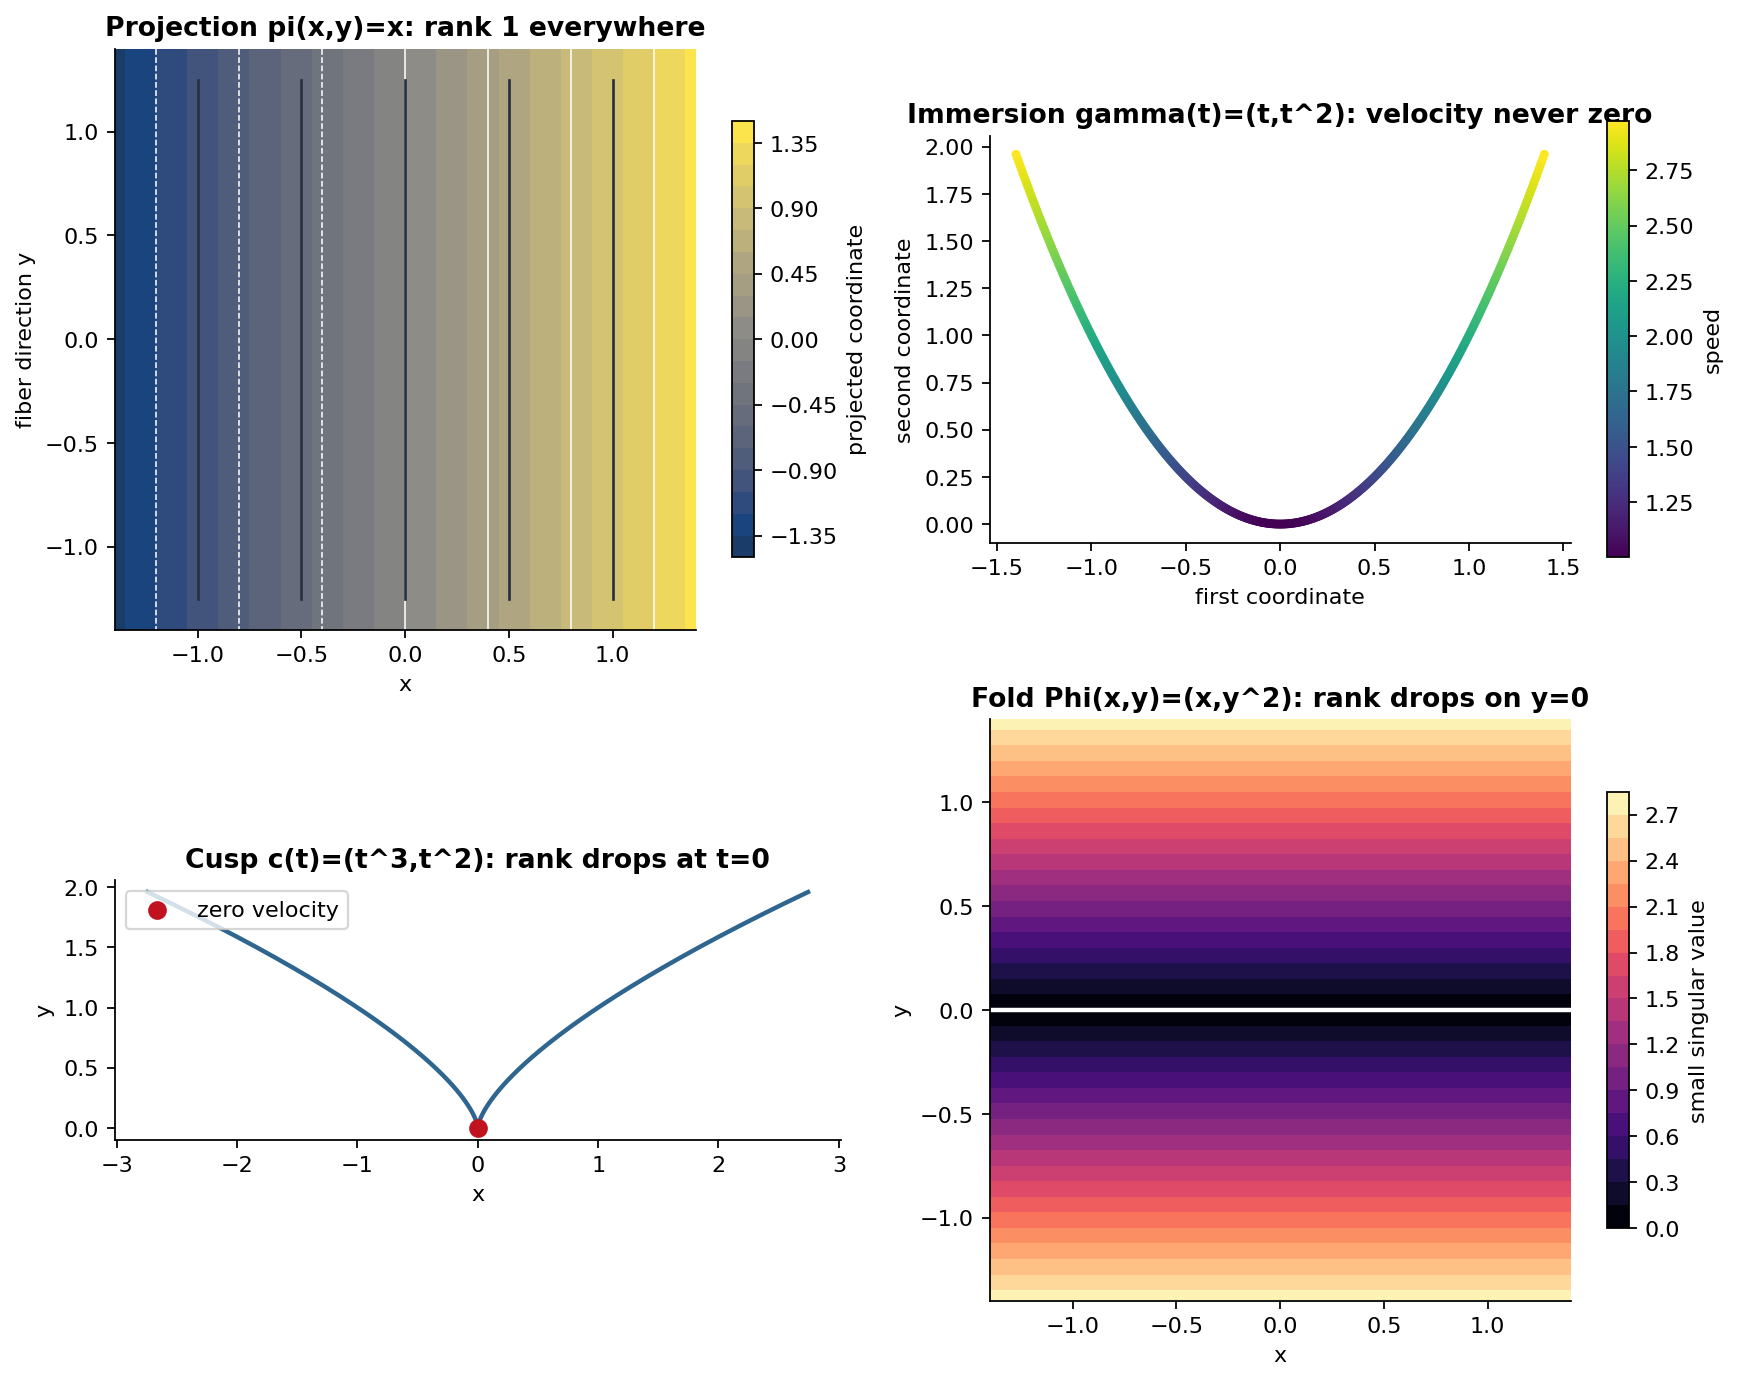

In [4]:
x, y, t = sp.symbols("x y t", real=True)
grid = np.linspace(-1.4, 1.4, 220)
X, Y = np.meshgrid(grid, grid)
T = np.linspace(-1.4, 1.4, 400)

fig, axs = plt.subplots(2, 2, figsize=(11, 9))

ax = axs[0, 0]
levels = ax.contourf(X, Y, X, levels=18, cmap="cividis", alpha=0.9)
ax.contour(X, Y, X, levels=np.linspace(-1.2, 1.2, 7), colors="white", linewidths=0.7)
for x0 in np.linspace(-1.0, 1.0, 5):
    ax.plot([x0, x0], [-1.25, 1.25], color="#273043", lw=1.2)
ax.set_title("Projection pi(x,y)=x: rank 1 everywhere")
ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("fiber direction y")

ax = axs[0, 1]
speed_parabola = np.sqrt(1 + (2 * T) ** 2)
sc = ax.scatter(T, T**2, c=speed_parabola, s=9, cmap="viridis")
ax.set_title("Immersion gamma(t)=(t,t^2): velocity never zero")
ax.set_aspect("equal")
ax.set_xlabel("first coordinate")
ax.set_ylabel("second coordinate")

ax = axs[1, 0]
speed_cusp = np.sqrt((3 * T**2) ** 2 + (2 * T) ** 2)
ax.plot(T**3, T**2, color="#2f6690", lw=2)
ax.scatter([0], [0], color="#c1121f", s=55, zorder=5, label="zero velocity")
ax.set_title("Cusp c(t)=(t^3,t^2): rank drops at t=0")
ax.legend(loc="upper left")
ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")

ax = axs[1, 1]
singular_value = 2 * np.abs(Y)
heat = ax.contourf(X, Y, singular_value, levels=20, cmap="magma")
ax.contour(X, Y, Y, levels=[0], colors="white", linewidths=2.0)
ax.set_title("Fold Phi(x,y)=(x,y^2): rank drops on y=0")
ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")

fig.colorbar(levels, ax=axs[0, 0], shrink=0.7, label="projected coordinate")
fig.colorbar(sc, ax=axs[0, 1], shrink=0.7, label="speed")
fig.colorbar(heat, ax=axs[1, 1], shrink=0.7, label="small singular value")
fig.tight_layout()
rank_examples_path = save_matplotlib(fig, FIGURES / "rank-field-examples.png")
plt.close(fig)

projection_jac = sp.Matrix([[1, 0]])
parabola_jac = sp.Matrix([[1], [2 * t]])
cusp_jac = sp.Matrix([[3 * t**2], [2 * t]])
fold_jac = sp.Matrix([[1, 0], [0, 2 * y]])
rank_examples_check = {
    "projection_rank": int(projection_jac.rank()),
    "projection_is_submersion_to_R": bool(projection_jac.rank() == 1),
    "parabola_min_sample_speed": float(speed_parabola.min()),
    "parabola_is_immersion_on_samples": bool(speed_parabola.min() > 0),
    "cusp_speed_at_zero": float(sp.sqrt((3 * t**2) ** 2 + (2 * t) ** 2).subs(t, 0)),
    "cusp_is_not_immersion_at_zero": True,
    "fold_rank_at_y_zero": int(fold_jac.subs(y, 0).rank()),
    "fold_rank_at_y_one": int(fold_jac.subs(y, 1).rank()),
    "fold_not_constant_rank": bool(fold_jac.subs(y, 0).rank() != fold_jac.subs(y, 1).rank()),
}
rank_examples_json = save_json(rank_examples_check, CHECKS / "rank-field-examples.json")
CREATED_ARTIFACTS.extend([rank_examples_path, rank_examples_json])
CHECK_SUMMARIES["rank_examples"] = rank_examples_check
display_artifact(rank_examples_path, width=850)


## Constant-Rank Normal Forms

The rank theorem says that after suitable charts, a constant-rank map looks like `(x_1,...,x_r,0,...,0)`. For a submersion, all target coordinates survive; for an immersion, all source coordinates survive.

In the figure, each panel is a normal form rather than a global claim about the original map. The moral is local: near the point, fibers and images can be straightened.


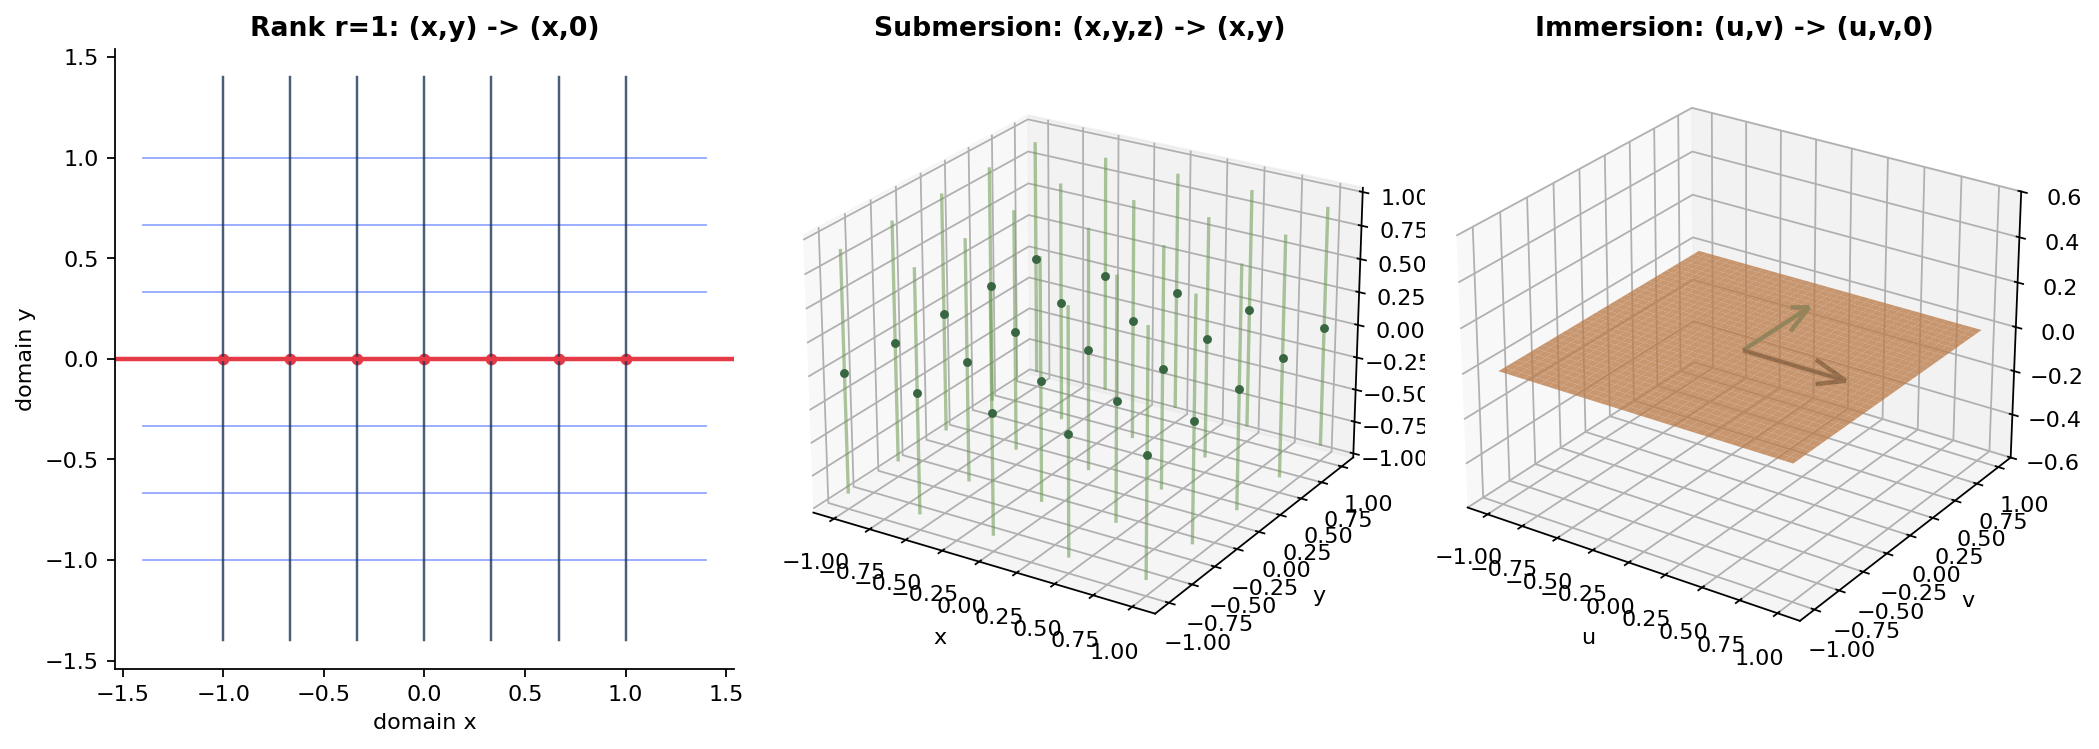

In [5]:
fig = plt.figure(figsize=(13, 4.5))

ax1 = fig.add_subplot(1, 3, 1)
for y0 in np.linspace(-1, 1, 7):
    ax1.plot(grid, np.full_like(grid, y0), color="#91a7ff", lw=0.8)
for x0 in np.linspace(-1, 1, 7):
    ax1.plot(np.full_like(grid, x0), grid, color="#1d3557", lw=1.1, alpha=0.8)
    ax1.scatter([x0], [0], color="#e63946", s=18)
ax1.axhline(0, color="#e63946", lw=2)
ax1.set_title("Rank r=1: (x,y) -> (x,0)")
ax1.set_xlabel("domain x")
ax1.set_ylabel("domain y")
ax1.set_aspect("equal")

ax2 = fig.add_subplot(1, 3, 2, projection="3d")
base = np.linspace(-1, 1, 5)
for x0 in base:
    for y0 in base:
        zline = np.linspace(-0.9, 0.9, 60)
        ax2.plot(np.full_like(zline, x0), np.full_like(zline, y0), zline, color="#6a994e", alpha=0.55)
        ax2.scatter([x0], [y0], [0], color="#386641", s=9)
ax2.set_title("Submersion: (x,y,z) -> (x,y)")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_zlabel("fiber")
ax2.view_init(elev=24, azim=-58)

ax3 = fig.add_subplot(1, 3, 3, projection="3d")
u = np.linspace(-1, 1, 35)
U, V = np.meshgrid(u, u)
ax3.plot_surface(U, V, np.zeros_like(U), color="#f4a261", alpha=0.78, linewidth=0, shade=True)
ax3.quiver(0, 0, 0, 0.7, 0, 0, color="#264653", linewidth=2)
ax3.quiver(0, 0, 0, 0, 0.7, 0, color="#2a9d8f", linewidth=2)
ax3.set_title("Immersion: (u,v) -> (u,v,0)")
ax3.set_xlabel("u")
ax3.set_ylabel("v")
ax3.set_zlabel("normal")
ax3.set_zlim(-0.6, 0.6)
ax3.view_init(elev=26, azim=-56)

fig.tight_layout()
normal_forms_path = save_matplotlib(fig, FIGURES / "constant-rank-normal-forms.png")
plt.close(fig)

general = sp.Matrix([[1, 0], [0, 0]])
submersion = sp.Matrix([[1, 0, 0], [0, 1, 0]])
immersion = sp.Matrix([[1, 0], [0, 1], [0, 0]])
normal_form_check = {
    "general_rank": int(general.rank()),
    "general_kernel_dimension": 2 - int(general.rank()),
    "submersion_rank": int(submersion.rank()),
    "submersion_surjective_to_R2": bool(submersion.rank() == 2),
    "immersion_rank": int(immersion.rank()),
    "immersion_injective_from_R2": bool(immersion.rank() == 2),
    "rank_theorem_model": "(x_1,...,x_r,x_{r+1},...,x_m) -> (x_1,...,x_r,0,...,0)",
}
normal_forms_json = save_json(normal_form_check, CHECKS / "constant-rank-normal-forms.json")
CREATED_ARTIFACTS.extend([normal_forms_path, normal_forms_json])
CHECK_SUMMARIES["constant_rank_normal_forms"] = normal_form_check
display_artifact(normal_forms_path, width=900)


## Inverse And Local Form Checks

The inverse function theorem is the square full-rank case. The following triangular map is deliberately simple:

\[
F(x,y)=(x+a y^2,y), \qquad F^{-1}(u,v)=(u-a v^2,v).
\]

Its determinant is `1`, so the inverse is smooth everywhere. The grid plot is a local diffeomorphism check with no hidden numerical solver.


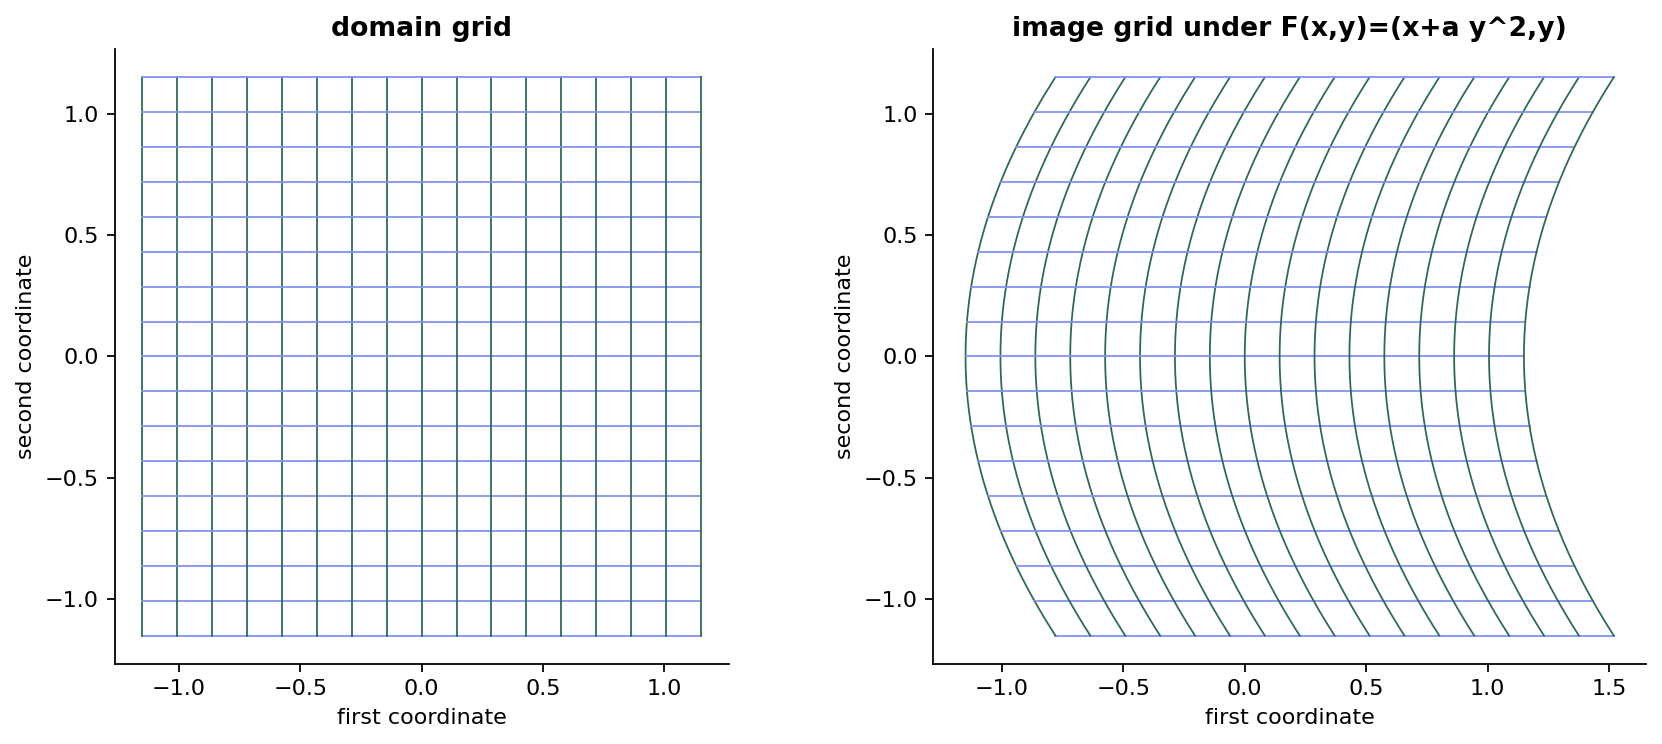

In [6]:
a = 0.28
line = np.linspace(-1.15, 1.15, 17)
fine = np.linspace(-1.15, 1.15, 180)

fig, axs = plt.subplots(1, 2, figsize=(11, 4.8))
for value in line:
    axs[0].plot(fine, np.full_like(fine, value), color="#8093f1", lw=0.8)
    axs[0].plot(np.full_like(fine, value), fine, color="#2d6a4f", lw=0.8)
    axs[1].plot(fine + a * value**2, np.full_like(fine, value), color="#8093f1", lw=0.8)
    axs[1].plot(np.full_like(fine, value) + a * fine**2, fine, color="#2d6a4f", lw=0.8)
axs[0].set_title("domain grid")
axs[1].set_title("image grid under F(x,y)=(x+a y^2,y)")
for ax in axs:
    ax.set_aspect("equal")
    ax.set_xlabel("first coordinate")
    ax.set_ylabel("second coordinate")
fig.tight_layout()
local_diff_path = save_matplotlib(fig, FIGURES / "local-diffeomorphism-grid.png")
plt.close(fig)

U, V = np.meshgrid(np.linspace(-1, 1, 61), np.linspace(-1, 1, 61))
image_u = U + a * V**2
image_v = V
recovered_x = image_u - a * image_v**2
recovered_y = image_v
inverse_residual = np.sqrt((recovered_x - U) ** 2 + (recovered_y - V) ** 2)

x, y = sp.symbols("x y", real=True)
J = sp.Matrix([[sp.diff(x + a * y**2, x), sp.diff(x + a * y**2, y)], [sp.diff(y, x), sp.diff(y, y)]])
local_diff_check = {
    "jacobian": [[str(entry) for entry in row] for row in J.tolist()],
    "determinant": str(sp.factor(J.det())),
    "rank": int(J.rank()),
    "max_inverse_residual_on_grid": float(inverse_residual.max()),
    "inverse_residual_below_tolerance": bool(inverse_residual.max() < 1e-12),
}
local_diff_json = save_json(local_diff_check, CHECKS / "local-diffeomorphism-grid.json")
CREATED_ARTIFACTS.extend([local_diff_path, local_diff_json])
CHECK_SUMMARIES["local_diffeomorphism"] = local_diff_check
display_artifact(local_diff_path, width=850)


## Immersions Versus Embeddings

The differential only sees infinitesimal behavior. Embedding is both infinitesimal and topological: the map must be an immersion and a homeomorphism onto its image.

These examples separate the conditions:

- The parabola is an embedding: regular, injective, and topologically tame.
- The cusp is topologically tame but not an immersion at the origin.
- The figure-eight style curve is a smooth injective immersion on an open interval, but its image topology disagrees with the domain because the ends accumulate at an image point.
- The irrational line on a torus is an injective immersion whose image winds densely, so it is not an embedding.


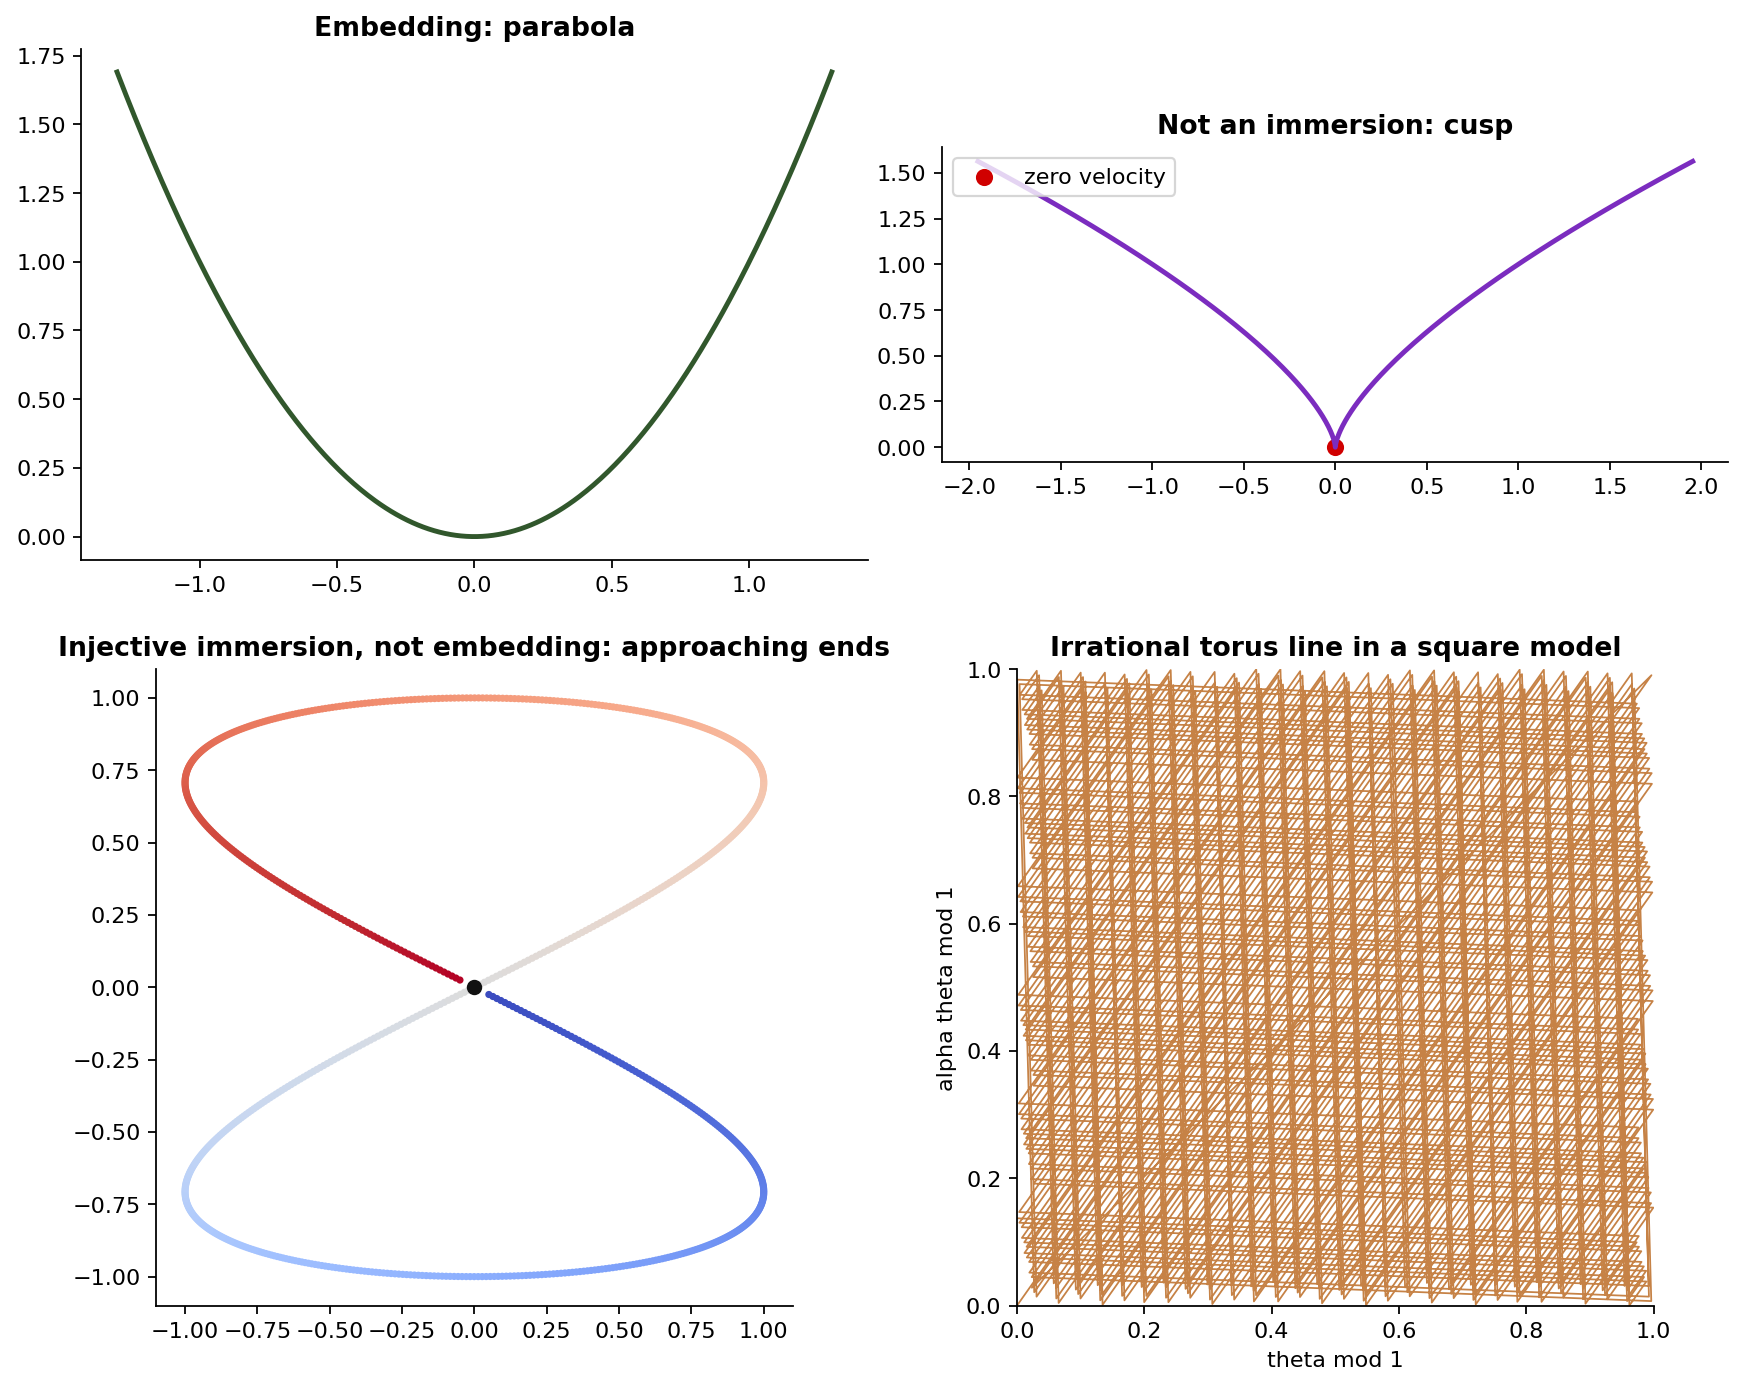

D:\Geometry\.venv\Lib\site-packages\IPython\core\display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


In [7]:
T_curve = np.linspace(-math.pi + 0.025, math.pi - 0.025, 900)
alpha = math.sqrt(2)
T_long = np.linspace(0, 80, 3000)
torus_square_x = np.mod(T_long, 1.0)
torus_square_y = np.mod(alpha * T_long, 1.0)

fig, axs = plt.subplots(2, 2, figsize=(11, 9))

tpar = np.linspace(-1.3, 1.3, 400)
axs[0, 0].plot(tpar, tpar**2, color="#31572c", lw=2.2)
axs[0, 0].set_title("Embedding: parabola")
axs[0, 0].set_aspect("equal")

tcusp = np.linspace(-1.25, 1.25, 400)
axs[0, 1].plot(tcusp**3, tcusp**2, color="#7b2cbf", lw=2.2)
axs[0, 1].scatter([0], [0], color="#d00000", s=45, label="zero velocity")
axs[0, 1].set_title("Not an immersion: cusp")
axs[0, 1].set_aspect("equal")
axs[0, 1].legend(loc="upper left")

beta_x = np.sin(2 * T_curve)
beta_y = np.sin(T_curve)
axs[1, 0].scatter(beta_x, beta_y, c=T_curve, cmap="coolwarm", s=5)
axs[1, 0].scatter([0], [0], color="#111111", s=35)
axs[1, 0].set_title("Injective immersion, not embedding: approaching ends")
axs[1, 0].set_aspect("equal")

axs[1, 1].plot(torus_square_x, torus_square_y, color="#bc6c25", lw=0.8, alpha=0.85)
axs[1, 1].set_title("Irrational torus line in a square model")
axs[1, 1].set_aspect("equal")
axs[1, 1].set_xlim(0, 1)
axs[1, 1].set_ylim(0, 1)
axs[1, 1].set_xlabel("theta mod 1")
axs[1, 1].set_ylabel("alpha theta mod 1")

fig.tight_layout()
embedding_path = save_matplotlib(fig, FIGURES / "immersion-embedding-counterexamples.png")
plt.close(fig)

# Interactive torus version of the irrational immersion.
theta = np.linspace(0, 45, 1800)
phi = alpha * theta
R, r = 2.1, 0.45
torus_x = (R + r * np.cos(2 * np.pi * phi)) * np.cos(2 * np.pi * theta)
torus_y = (R + r * np.cos(2 * np.pi * phi)) * np.sin(2 * np.pi * theta)
torus_z = r * np.sin(2 * np.pi * phi)
fig_torus = go.Figure()
fig_torus.add_trace(go.Scatter3d(
    x=torus_x,
    y=torus_y,
    z=torus_z,
    mode="lines",
    line=dict(color=np.linspace(0, 1, len(theta)), colorscale="Turbo", width=4),
    name="irrational immersed line",
))
fig_torus.update_layout(
    title="Irrational-slope immersion into the torus: long finite trace",
    scene=dict(aspectmode="data", xaxis_title="x", yaxis_title="y", zaxis_title="z"),
    margin=dict(l=0, r=0, t=45, b=0),
    height=680,
)
dense_torus_html = ensure_parent(HTML / "dense-torus-immersion.html")
fig_torus.write_html(str(dense_torus_html), include_plotlyjs=True, full_html=True)

n = np.arange(1, 1500)
dirichlet_residuals = np.abs(alpha * n - np.round(alpha * n))
figure_eight_end_distance = float(np.linalg.norm([np.sin(2 * (math.pi - 0.025)), np.sin(math.pi - 0.025)]))
embedding_check = {
    "parabola_min_speed": float(np.sqrt(1 + (2 * tpar) ** 2).min()),
    "cusp_speed_at_zero": 0.0,
    "figure_eight_endpoint_image_distance_to_origin": figure_eight_end_distance,
    "figure_eight_velocity_min_sample": float(np.sqrt((2 * np.cos(2 * T_curve)) ** 2 + np.cos(T_curve) ** 2).min()),
    "irrational_alpha": alpha,
    "best_integer_return_under_1500": float(dirichlet_residuals.min()),
    "best_return_index": int(n[np.argmin(dirichlet_residuals)]),
    "torus_trace_points": int(len(theta)),
    "conceptual_flags": {
        "cusp_topological_embedding_but_not_smooth_embedding": True,
        "figure_eight_style_curve_not_topological_embedding": True,
        "irrational_torus_line_injective_immersion_not_embedding": True,
    },
}
embedding_json = save_json(embedding_check, CHECKS / "immersion-embedding-counterexamples.json")
CREATED_ARTIFACTS.extend([embedding_path, dense_torus_html, embedding_json])
CHECK_SUMMARIES["immersion_embedding_counterexamples"] = embedding_check
display_artifact(embedding_path, width=850)
display_artifact(dense_torus_html, width=850, height=620)


## Submersions As Projections And Level-Set Tests

A submersion is the nonlinear analogue of a surjective linear map. Locally, it looks like a projection; its fibers look like coordinate slices; and a scalar function has regular level sets where its gradient is nonzero.

The panels compare:

- a projection with vertical fibers,
- the unit circle as a regular level of `x^2+y^2`,
- the cross `xy=0`, whose level set is singular at the origin because the gradient vanishes there.


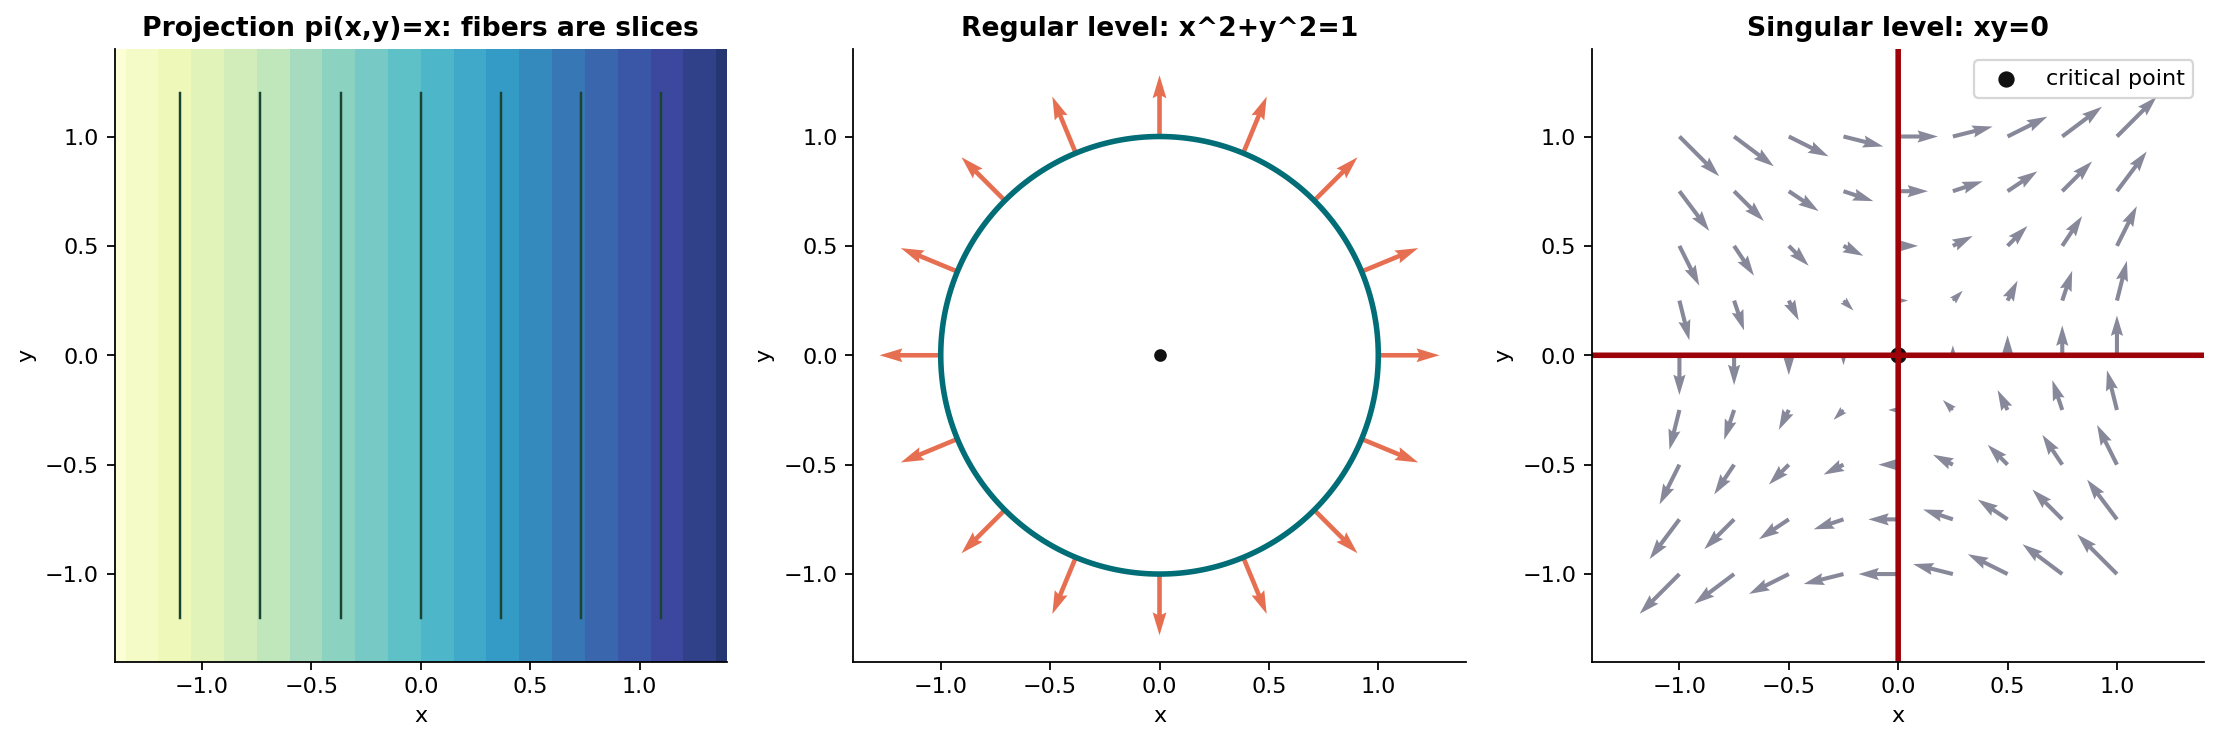

In [8]:
Z_circle = X**2 + Y**2
Z_cross = X * Y

fig, axs = plt.subplots(1, 3, figsize=(14, 4.8))

axs[0].contourf(X, Y, X, levels=18, cmap="YlGnBu", alpha=0.9)
for x0 in np.linspace(-1.1, 1.1, 7):
    axs[0].plot([x0, x0], [-1.2, 1.2], color="#1b4332", lw=1.1)
axs[0].set_title("Projection pi(x,y)=x: fibers are slices")
axs[0].set_aspect("equal")

axs[1].contour(X, Y, Z_circle, levels=[1.0], colors="#006d77", linewidths=2.5)
sample_angles = np.linspace(0, 2 * np.pi, 16, endpoint=False)
px, py = np.cos(sample_angles), np.sin(sample_angles)
axs[1].quiver(px, py, 0.28 * px, 0.28 * py, angles="xy", scale_units="xy", scale=1, color="#e76f51")
axs[1].scatter([0], [0], color="#111111", s=22)
axs[1].set_title("Regular level: x^2+y^2=1")
axs[1].set_aspect("equal")

axs[2].contour(X, Y, Z_cross, levels=[0.0], colors="#9d0208", linewidths=2.5)
q = np.linspace(-1.0, 1.0, 9)
QX, QY = np.meshgrid(q, q)
axs[2].quiver(QX, QY, QY, QX, color="#3d405b", alpha=0.62)
axs[2].scatter([0], [0], color="#111111", s=40, label="critical point")
axs[2].set_title("Singular level: xy=0")
axs[2].legend(loc="upper right")
axs[2].set_aspect("equal")

for ax in axs:
    ax.set_xlabel("x")
    ax.set_ylabel("y")
fig.tight_layout()
submersion_level_path = save_matplotlib(fig, FIGURES / "submersion-level-set-tests.png")
plt.close(fig)

circle_grad = sp.Matrix([2 * x, 2 * y])
cross_grad = sp.Matrix([y, x])
submersion_level_check = {
    "projection_jacobian_rank": int(sp.Matrix([[1, 0]]).rank()),
    "circle_gradient_on_unit_point": [str(v) for v in circle_grad.subs({x: 1, y: 0})],
    "circle_gradient_rank_on_unit_point": int(sp.Matrix([circle_grad.subs({x: 1, y: 0})]).rank()),
    "circle_level_one_regular_on_samples": bool(np.min(np.sqrt((2 * px) ** 2 + (2 * py) ** 2)) > 0),
    "cross_gradient_at_origin": [str(v) for v in cross_grad.subs({x: 0, y: 0})],
    "cross_has_critical_point_on_zero_level": True,
    "submersion_projection_model": "(x,y,z) -> (x,y)",
}
submersion_level_json = save_json(submersion_level_check, CHECKS / "submersion-level-set-tests.json")
CREATED_ARTIFACTS.extend([submersion_level_path, submersion_level_json])
CHECK_SUMMARIES["submersion_level_sets"] = submersion_level_check
display_artifact(submersion_level_path, width=900)


## Smooth Covering Maps

A smooth covering map is a local diffeomorphism with repeated sheets. The basic example is the exponential cover of the circle:

\[
p(\theta)=(\cos \theta,\sin \theta).
\]

A short arc in the circle lifts to disjoint intervals in the real line. Choosing one sheet gives a smooth local section, and over an evenly covered connected arc that choice is unique once the lifted point is specified.


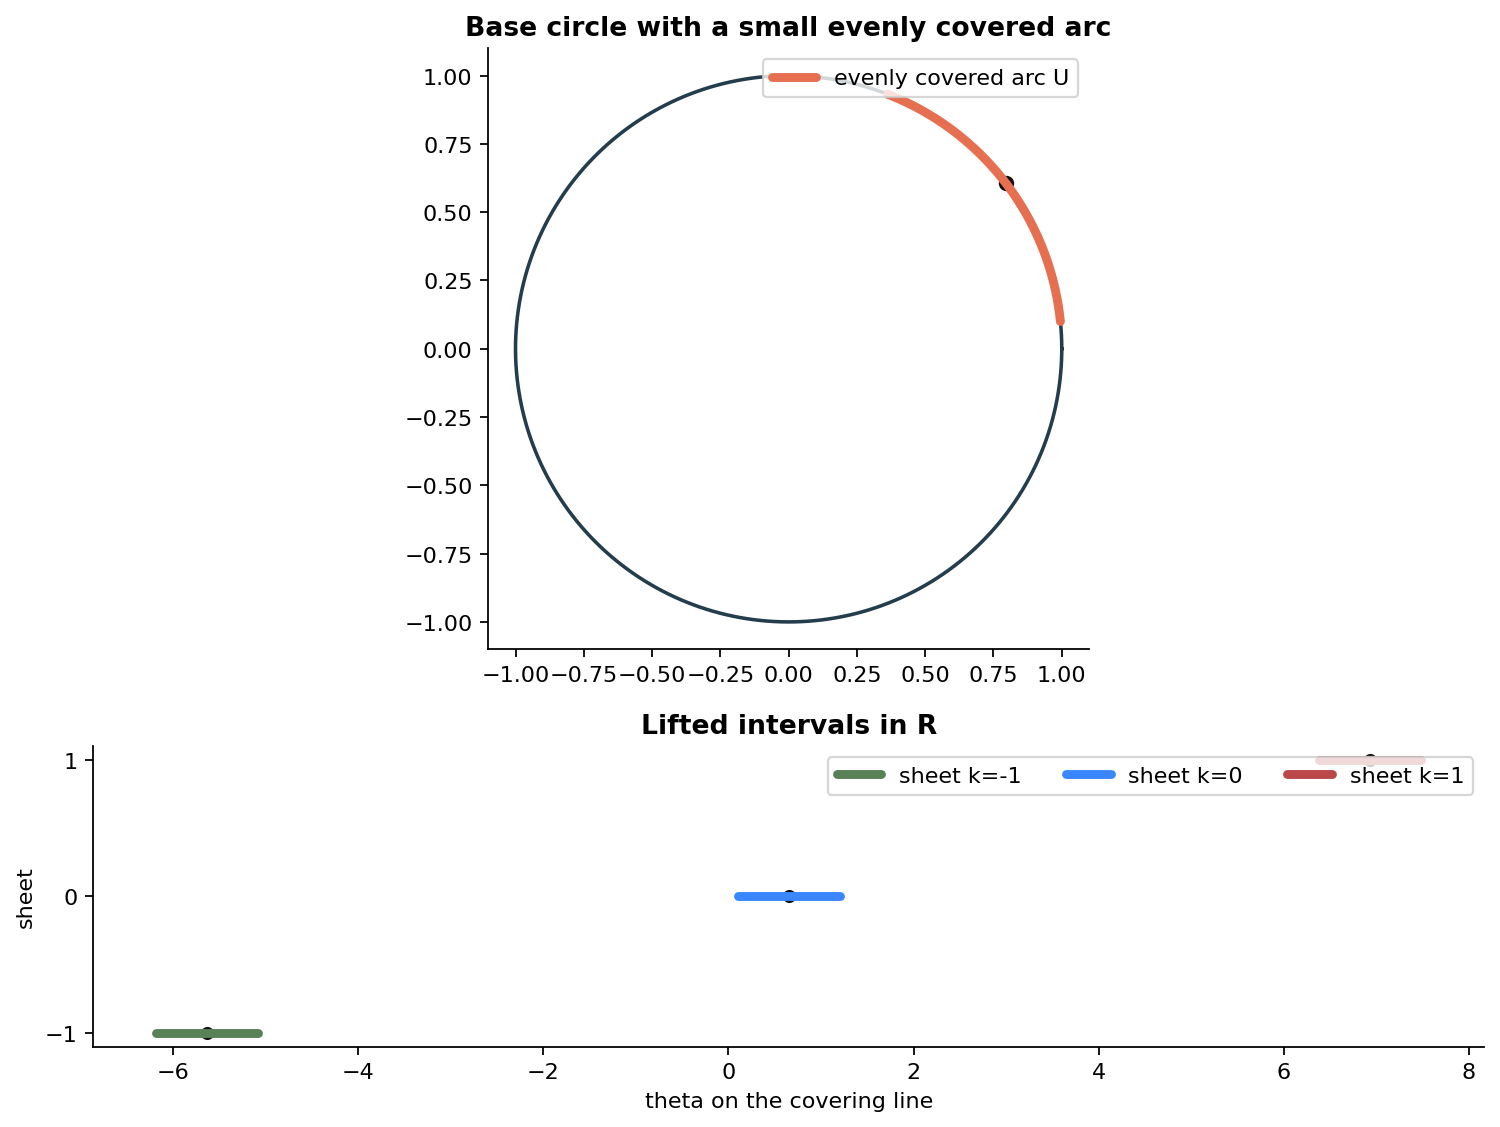

In [9]:
theta0 = 0.65
radius = 0.55
base_theta = np.linspace(theta0 - radius, theta0 + radius, 220)
sheets = [-1, 0, 1]

fig, axs = plt.subplots(2, 1, figsize=(9.5, 7.2), gridspec_kw={"height_ratios": [2, 1]})
circle_theta = np.linspace(0, 2 * np.pi, 500)
axs[0].plot(np.cos(circle_theta), np.sin(circle_theta), color="#233d4d", lw=1.6)
axs[0].plot(np.cos(base_theta), np.sin(base_theta), color="#e76f51", lw=4.0, solid_capstyle="round", label="evenly covered arc U")
axs[0].scatter([np.cos(theta0)], [np.sin(theta0)], color="#111111", s=35)
axs[0].set_aspect("equal")
axs[0].set_title("Base circle with a small evenly covered arc")
axs[0].legend(loc="upper right")

colors = ["#588157", "#3a86ff", "#bc4749"]
for color, k in zip(colors, sheets):
    lifted = base_theta + 2 * np.pi * k
    axs[1].plot(lifted, np.full_like(lifted, k), color=color, lw=4.0, solid_capstyle="round", label=f"sheet k={k}")
    axs[1].scatter([theta0 + 2 * np.pi * k], [k], color="#111111", s=24)
axs[1].set_yticks(sheets)
axs[1].set_xlabel("theta on the covering line")
axs[1].set_ylabel("sheet")
axs[1].set_title("Lifted intervals in R")
axs[1].legend(loc="upper right", ncol=3)
fig.tight_layout()
covering_path = save_matplotlib(fig, FIGURES / "smooth-covering-local-sections.png")
plt.close(fig)

helix_theta = np.linspace(-4 * np.pi, 4 * np.pi, 1200)
fig_cover = go.Figure()
fig_cover.add_trace(go.Scatter3d(
    x=np.cos(helix_theta),
    y=np.sin(helix_theta),
    z=helix_theta / (2 * np.pi),
    mode="lines",
    line=dict(color=helix_theta, colorscale="Viridis", width=5),
    name="covering line as helix",
))
fig_cover.add_trace(go.Scatter3d(
    x=np.cos(circle_theta),
    y=np.sin(circle_theta),
    z=np.zeros_like(circle_theta),
    mode="lines",
    line=dict(color="#111111", width=3),
    name="base circle",
))
fig_cover.add_trace(go.Scatter3d(
    x=np.cos(base_theta),
    y=np.sin(base_theta),
    z=np.zeros_like(base_theta),
    mode="lines",
    line=dict(color="#e76f51", width=8),
    name="evenly covered arc",
))
fig_cover.update_layout(
    title="Smooth covering map p(theta)=(cos theta, sin theta)",
    scene=dict(aspectmode="data", xaxis_title="cos theta", yaxis_title="sin theta", zaxis_title="sheet height"),
    margin=dict(l=0, r=0, t=45, b=0),
    height=680,
)
covering_html = ensure_parent(HTML / "smooth-covering-local-sections.html")
fig_cover.write_html(str(covering_html), include_plotlyjs=True, full_html=True)

section_residuals = []
for k in sheets:
    lifted = base_theta + 2 * np.pi * k
    residual = np.sqrt((np.cos(lifted) - np.cos(base_theta)) ** 2 + (np.sin(lifted) - np.sin(base_theta)) ** 2)
    section_residuals.append(float(residual.max()))
covering_check = {
    "derivative_norm_min_on_samples": float(np.sqrt((-np.sin(base_theta)) ** 2 + (np.cos(base_theta)) ** 2).min()),
    "number_of_displayed_sheets": len(sheets),
    "local_section_composition_residuals": section_residuals,
    "local_sections_compose_to_identity": bool(max(section_residuals) < 1e-12),
    "sheet_intervals_are_disjoint": bool((theta0 + radius) < (theta0 - radius + 2 * np.pi)),
}
covering_json = save_json(covering_check, CHECKS / "smooth-covering-local-sections.json")
CREATED_ARTIFACTS.extend([covering_path, covering_html, covering_json])
CHECK_SUMMARIES["smooth_covering_maps"] = covering_check
display_artifact(covering_path, width=820)
display_artifact(covering_html, width=850, height=620)


## Applied Lab: Where A Submersion Fails

Vary the parameter `a` in

\[
F_a(x,y)=(x, y^3-a y).
\]

The Jacobian determinant is `3y^2-a`. For `a<0`, this example is a local diffeomorphism everywhere. At `a=0`, the rank drops on `y=0`. For `a>0`, rank drops on the two horizontal lines `y=\pm\sqrt{a/3}`. This is a compact way to see why constant-rank hypotheses are not cosmetic.


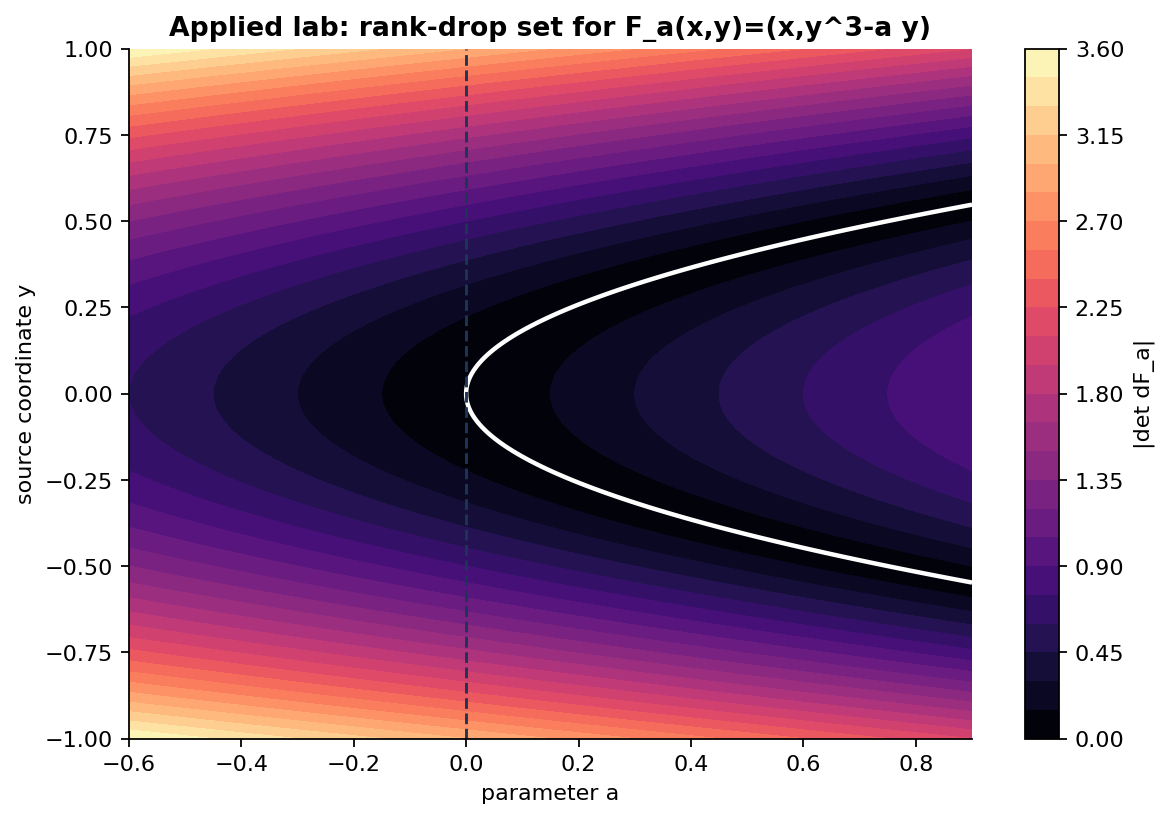

Lab table: `artifacts\chapter-04-submersions-immersions-and-embeddings\tables\applied-lab-rank-parameter-scan.csv`

In [10]:
a_values = np.linspace(-0.6, 0.9, 220)
y_values = np.linspace(-1.0, 1.0, 260)
A, YY = np.meshgrid(a_values, y_values)
det_family = 3 * YY**2 - A

fig, ax = plt.subplots(figsize=(8.5, 5.6))
im = ax.contourf(A, YY, np.abs(det_family), levels=30, cmap="rocket_r" if "rocket_r" in plt.colormaps() else "magma")
ax.contour(A, YY, det_family, levels=[0], colors="white", linewidths=2.0)
ax.axvline(0, color="#1d3557", lw=1.3, linestyle="--")
ax.set_title("Applied lab: rank-drop set for F_a(x,y)=(x,y^3-a y)")
ax.set_xlabel("parameter a")
ax.set_ylabel("source coordinate y")
fig.colorbar(im, ax=ax, label="|det dF_a|")
lab_path = save_matplotlib(fig, FIGURES / "applied-lab-rank-parameter-scan.png")
plt.close(fig)

lab_rows = []
for aval in [-0.5, 0.0, 0.3, 0.75]:
    if aval < 0:
        critical = "none"
        critical_count = 0
    elif aval == 0:
        critical = "0"
        critical_count = 1
    else:
        root = math.sqrt(aval / 3)
        critical = f"+/-{root:.6f}"
        critical_count = 2
    lab_rows.append({
        "a": aval,
        "determinant": "3*y^2-a",
        "critical_y_values": critical,
        "rank_drop_lines": critical_count,
    })
lab_table_path = save_csv(lab_rows, TABLES / "applied-lab-rank-parameter-scan.csv")
lab_check = {
    "determinant_formula": "3*y^2-a",
    "negative_a_has_no_rank_drop": True,
    "zero_a_rank_drop_at_y_zero": True,
    "positive_a_has_two_rank_drop_lines": True,
    "sample_rows": lab_rows,
}
lab_json = save_json(lab_check, CHECKS / "applied-lab-rank-parameter-scan.json")
CREATED_ARTIFACTS.extend([lab_path, lab_table_path, lab_json])
CHECK_SUMMARIES["applied_lab"] = lab_check
display_artifact(lab_path, width=760)
display(Markdown(f"Lab table: `{lab_table_path.relative_to(BOOK_ROOT)}`"))


## Computational Checks

The notebook's checks are intentionally small and inspectable. They do not prove the theorems, but each one guards a chapter claim:

- rank calculations match the intended submersion, immersion, local diffeomorphism, and rank-drop examples;
- normal-form matrices have the expected kernel/image dimensions;
- the explicit inverse has negligible residual;
- level-set examples separate regular and singular fibers;
- covering-map local sections compose back to the base arc;
- every generated artifact exists and is nonempty.


In [11]:
key_checks = {
    "proof_graph_is_dag": CHECK_SUMMARIES["proof_dependency_graph"]["is_directed_acyclic_graph"],
    "projection_is_submersion": CHECK_SUMMARIES["rank_examples"]["projection_is_submersion_to_R"],
    "fold_not_constant_rank": CHECK_SUMMARIES["rank_examples"]["fold_not_constant_rank"],
    "submersion_normal_form_is_surjective": CHECK_SUMMARIES["constant_rank_normal_forms"]["submersion_surjective_to_R2"],
    "immersion_normal_form_is_injective": CHECK_SUMMARIES["constant_rank_normal_forms"]["immersion_injective_from_R2"],
    "local_inverse_residual_ok": CHECK_SUMMARIES["local_diffeomorphism"]["inverse_residual_below_tolerance"],
    "circle_level_regular": CHECK_SUMMARIES["submersion_level_sets"]["circle_level_one_regular_on_samples"],
    "covering_sections_ok": CHECK_SUMMARIES["smooth_covering_maps"]["local_sections_compose_to_identity"],
    "lab_positive_a_two_lines": CHECK_SUMMARIES["applied_lab"]["positive_a_has_two_rank_drop_lines"],
}
for name, passed in key_checks.items():
    assert bool(passed), name
print(json.dumps(key_checks, indent=2))


{
  "proof_graph_is_dag": true,
  "projection_is_submersion": true,
  "fold_not_constant_rank": true,
  "submersion_normal_form_is_surjective": true,
  "immersion_normal_form_is_injective": true,
  "local_inverse_residual_ok": true,
  "circle_level_regular": true,
  "covering_sections_ok": true,
  "lab_positive_a_two_lines": true
}


## Takeaways

- Rank is the invariant that survives coordinate changes, so it is the right first diagnostic for smooth maps.
- Constant rank is the hypothesis that lets the nonlinear map be straightened into a projection/inclusion normal form.
- Submersions are locally projections and admit local sections; surjective submersions behave like smooth quotient maps.
- Immersions are locally embeddings, but global embedding requires the image topology to match the domain.
- Smooth covering maps are local diffeomorphisms organized into repeated sheets; local sections choose one sheet over an evenly covered neighborhood.
- Counterexamples are part of the theory: cusps, folds, figure-eight style curves, dense torus lines, and singular level sets show exactly which hypothesis is doing work.


In [12]:
# final_sanity
assert_artifacts(CREATED_ARTIFACTS, min_bytes=80)
final_sanity = {
    "unit": UNIT_TITLE,
    "source_span": SOURCE_SPAN,
    "artifact_count_before_final_json": len(CREATED_ARTIFACTS),
    "artifacts": [str(path.relative_to(BOOK_ROOT)) for path in CREATED_ARTIFACTS],
    "checks": key_checks,
    "check_summaries": CHECK_SUMMARIES,
}
final_sanity_path = save_json(final_sanity, CHECKS / "final_sanity.json")
assert_artifacts([final_sanity_path], min_bytes=80)
display_artifact(final_sanity_path)
print(f"final_sanity passed with {len(CREATED_ARTIFACTS) + 1} artifacts, including final_sanity.json")


`final_sanity.json`

final_sanity passed with 21 artifacts, including final_sanity.json
